과제
---------
sklearn 의 breast_cancer 데이터셋

1. train, test 나누기
2. 정규화
3. 케라스 학습
4. train, test 각각 confusion matrix(heat map 포함), f1, acc
5. 1번째행 예측값

In [23]:
import tensorflow as tf
from keras.optimizers import Adam
from keras import Sequential
from keras.layers import Dense
from keras.utils import to_categorical
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression, LinearRegression,SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.datasets import load_breast_cancer

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family']='Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False


In [24]:
cancer = load_breast_cancer(as_frame=True)
cancer['frame']

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [41]:
x_data = cancer['data'].values
y_data = cancer['target'].values

In [42]:
x_data.shape

(569, 30)

In [43]:
y_data.shape

(569,)

1. train, test 나누기

In [44]:
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.2, random_state=42, stratify=y_data)

In [45]:
y_train

array([1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0,
       0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1,

2. 정규화

In [92]:
scaleF = StandardScaler()
x_dataN = scaleF.fit_transform( x_data)

3. 케라스 학습

In [93]:
dense = Dense(units=1, input_dim=30, activation='sigmoid')
model = Sequential([dense])
model.compile( loss='binary_crossentropy', optimizer=Adam(0.1) , metrics=['acc'] )
h = model.fit( x_train, y_train, epochs=500)

Epoch 1/500


c:\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.5077 - loss: 34.3474   
Epoch 2/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7099 - loss: 5.3283 
Epoch 3/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8527 - loss: 2.8867 
Epoch 4/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8593 - loss: 2.3704 
Epoch 5/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8527 - loss: 2.2241 
Epoch 6/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8857 - loss: 1.3812 
Epoch 7/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8901 - loss: 0.8127 
Epoch 8/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9033 - loss: 0.6599 
Epoch 9/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8989 - loss: 1.0045 
Epoch 10/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8440 - loss: 2.4029 
Epoch 11/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8703 - loss: 1.2559 
Epoch 12/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8945 - loss: 1.2832 
Epoch 13/500
15/15 ━━━━━━━━━━━━━━━

4. train, test 각각 confusion matrix(heat map 포함), f1, acc

In [66]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
import seaborn as sb

In [ ]:
y_prob = model.predict(x_train).ravel()  # ravel = 1차원으로 펼치기
y_pred = (y_prob >= 0.5).astype(int)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


array([1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1,

In [ ]:
y_prob_t = model.predict(x_test).ravel()  # ravel = 1차원으로 펼치기
y_pred_t = (y_prob >= 0.5).astype(int)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


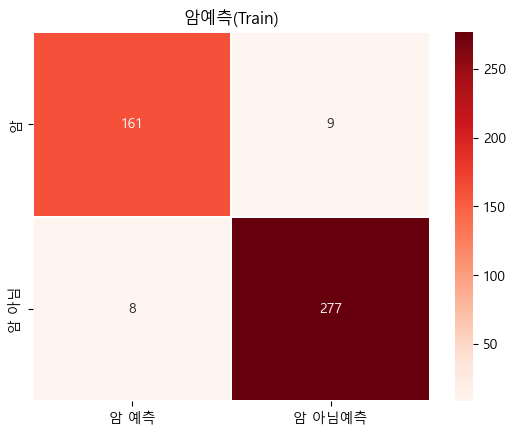

In [109]:
c = confusion_matrix(y_train, y_pred)
sb.heatmap(c, annot=True, fmt='d', linewidths=0.2, cmap='Reds',
            xticklabels=['암 예측', '암 아님예측'], yticklabels=['암', '암 아님'])
plt.title('암예측(Train)')
plt.show()

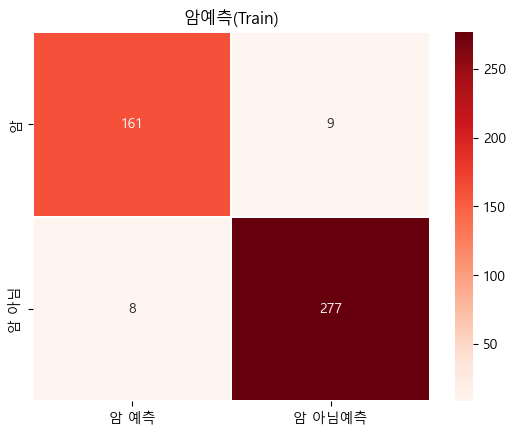

In [ ]:
c = confusion_matrix(y_train, y_pred)
sb.heatmap(c, annot=True, fmt='d', linewidths=0.2, cmap='Reds',
            xticklabels=['암 예측', '암 아님예측'], yticklabels=['암', '암 아님'])
plt.title('암예측(Train)')
plt.show()

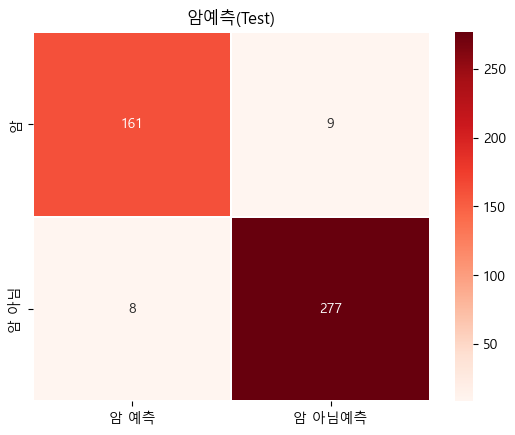

In [108]:
ct = confusion_matrix(y_test, y_pred_t)
sb.heatmap(c, annot=True, fmt='d', linewidths=0.2, cmap='Reds',
            xticklabels=['암 예측', '암 아님예측'], yticklabels=['암', '암 아님'])
plt.title('암예측(Test)')
plt.show()

In [104]:
print('train 정확도', accuracy_score(y_train, y_pred) )
print('train f1 score', f1_score(y_train, y_pred) )

train 정확도 0.9626373626373627
train f1 score 0.9702276707530648


In [103]:
print('test 정확도', accuracy_score(y_test, y_pred_t) )
print('test f1 score', f1_score(y_test, y_pred_t) )

test 정확도 0.9473684210526315
test f1 score 0.9571428571428572


In [97]:
model.predict(x_dataN[[0]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


array([[0.]], dtype=float32)